# Análisis de ROC-AUC por segmentos — delta_10m, delta_20m y delta_30m

Train: enero–octubre 2025  
Validación (early stopping): noviembre–diciembre 2025  
Test: enero 2026  

**Modelo binario**: predice si el retraso **mejorará** (se reducirá) en el horizonte indicado.
- **Clase 1** (mejora): `delta_delay_Xm < 0`
- **Clase 0** (no mejora): `delta_delay_Xm >= 0`

**Métrica principal**: ROC-AUC  
También se reporta PR-AUC (área bajo la curva Precision-Recall).

Slices analizados en cada horizonte:
- Por línea (`route_id`)
- Fin de semana vs laborable
- Hora punta vs fuera de punta (7-9h y 17-19h)
- Por día de semana

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, roc_curve, precision_recall_curve,
)

from src.common.minio_client import download_df_parquet

In [2]:
ACCESS_KEY = os.environ['MINIO_ACCESS_KEY']
SECRET_KEY = os.environ['MINIO_SECRET_KEY']

DATA_TEMPLATE = 'grupo5/final/year={year}/month={month:02d}/dataset_final.parquet'

TARGET = 'target_mejora'  # 1 si delta < 0, 0 si delta >= 0

# is_unscheduled excluido: se filtra en load_months, siempre False tras el filtrado
CAT_FEATURES = [
    'route_id', 'direction', 'category', 'tipo_referente',
    'stop_id', 'is_weekend', 'temp_extreme',
    'afecta_previo', 'afecta_durante', 'afecta_despues',
    'is_alert_just_published', 'has_alert',
]

EXCLUDE_COLS = {
    'date', 'match_key', 'merge_time', 'timestamp_start',
    'service_date', 'trip_uid', 'is_unscheduled',
    'target_delay_10m', 'target_delay_20m', 'target_delay_30m',
    'target_delay_45m', 'target_delay_60m', 'target_delay_end',
    'delta_delay_10m', 'delta_delay_20m', 'delta_delay_30m',
    'delta_delay_45m', 'delta_delay_60m', 'delta_delay_end',
    'alert_in_next_15m', 'alert_in_next_30m', 'seconds_to_next_alert',
    'delay_minutes', 'scheduled_time', 'actual_time',
    '_route_id', '_dow', '_is_weekend', '_hour', '_is_rush',
    'target_mejora',
}

DOW_NAMES = {0: 'Lunes', 1: 'Martes', 2: 'Miércoles', 3: 'Jueves',
             4: 'Viernes', 5: 'Sábado', 6: 'Domingo'}

LGBM_PARAMS = {
    'objective':         'binary',
    'metric':            'auc',
    'learning_rate':     0.05,
    'num_leaves':        127,
    'min_child_samples': 100,
    'feature_fraction':  0.8,
    'bagging_fraction':  0.8,
    'bagging_freq':      5,
    'reg_alpha':         0.1,
    'reg_lambda':        1.0,
    'n_jobs':            -1,
    'verbose':           -1,
    'seed':              42,
}
NUM_BOOST_ROUND = 3000
EARLY_STOPPING  = 50

In [3]:
def load_months(year, months, target_delta):
    """Descarga los meses indicados desde MinIO, filtrando viajes programados."""
    dfs = []
    for month in months:
        path = DATA_TEMPLATE.format(year=year, month=month)
        try:
            df = download_df_parquet(ACCESS_KEY, SECRET_KEY, path)
            df = df[df['is_unscheduled'] == False]
            df = df.dropna(subset=[target_delta])
            for col in CAT_FEATURES:
                if col in df.columns:
                    df[col] = df[col].astype('category')
            print(f'  {year}-{month:02d}: {len(df):,} filas')
            dfs.append(df)
        except Exception as e:
            print(f'  {year}-{month:02d}: error ({e})')
    return pd.concat(dfs, ignore_index=True)


def add_slice_cols(df):
    """Añade columnas auxiliares para los slices (antes del encode categórico)."""
    df['_route_id']   = df['route_id'].astype(str)
    df['_dow']        = df['dow'].astype(int) if 'dow' in df.columns else -1
    df['_is_weekend'] = df['is_weekend'].astype(int) if 'is_weekend' in df.columns else -1
    if 'hour_sin' in df.columns and 'hour_cos' in df.columns:
        angle = np.arctan2(df['hour_sin'].astype(float), df['hour_cos'].astype(float))
        df['_hour']    = (angle * 24 / (2 * np.pi)) % 24
        df['_is_rush'] = df['_hour'].apply(lambda h: 1 if (7 <= h < 9) or (17 <= h < 19) else 0)
    return df


def add_features(df):
    """Feature engineering específico del modelo delta: tendencia, inercia y alertas."""
    df = df.copy()
    df['delay_change']      = df['delay_seconds'] - df['lagged_delay_1']
    df['delay_change_prev'] = df['lagged_delay_1'] - df['lagged_delay_2']
    df['delay_accel']       = df['delay_change'] - df['delay_change_prev']
    df['delay_vs_route']    = df['delay_seconds'] - df['route_rolling_delay']
    df['delay_vs_station']  = df['delay_seconds'] - df['station_delay_10m'].fillna(df['delay_seconds'])
    df['station_trend']     = df['station_delay_10m'] - df['station_delay_20m']
    df['delay_time_ratio']  = df['delay_seconds'] / (df['scheduled_time_to_end'] + 1.0)
    df['has_alert']         = (df['n_eventos_afectando'] > 0).astype(np.int8)
    # cast a int antes de sumar: afecta_* pueden ser dtype category tras load_months
    df['alert_impact']      = (
        df['afecta_previo'].astype(int)
        + df['afecta_durante'].astype(int)
        + df['afecta_despues'].astype(int)
    )
    return df


def encode_categoricals(df_tr, df_val, df_te):
    """Label encoding con vocabulario de train; desconocidos → -1."""
    for col in CAT_FEATURES:
        if col not in df_tr.columns:
            continue
        vocab = {v: i for i, v in enumerate(df_tr[col].astype(str).unique())}
        df_tr[col]  = df_tr[col].astype(str).map(vocab).astype(int)
        df_val[col] = df_val[col].astype(str).map(vocab).fillna(-1).astype(int)
        df_te[col]  = df_te[col].astype(str).map(vocab).fillna(-1).astype(int)
    return df_tr, df_val, df_te


def get_features(df, target):
    """Devuelve features usables (excluye targets, IDs y auxiliares de slice)."""
    return [c for c in df.columns if c not in EXCLUDE_COLS and c != target]


print('Funciones auxiliares cargadas.')

Funciones auxiliares cargadas.


In [4]:
# ── Análisis por segmento ──────────────────────────────────────────────────────

def compute_slices_auc(df_in, target):
    """Calcula ROC-AUC y PR-AUC por segmento (línea, fin de semana, hora punta, día)."""
    required = ['_pred_prob', target, '_route_id', '_is_weekend', '_is_rush', '_dow']
    missing = [c for c in required if c not in df_in.columns]
    if missing:
        raise KeyError(f'Faltan columnas para compute_slices_auc: {missing}')

    slice_df = df_in[required]

    def _stats(g):
        y = g[target].to_numpy(copy=False)
        p = g['_pred_prob'].to_numpy(copy=False)
        if len(np.unique(y)) < 2:
            return pd.Series({'n_filas': len(g), 'roc_auc': np.nan, 'pr_auc': np.nan})
        return pd.Series({
            'n_filas': len(g),
            'roc_auc': round(float(roc_auc_score(y, p)), 4),
            'pr_auc':  round(float(average_precision_score(y, p)), 4),
        })

    # ROC-AUC por línea de metro (route_id), ordenado de menor a mayor AUC
    by_line = (slice_df.groupby('_route_id', observed=True).apply(_stats)
               .reset_index().rename(columns={'_route_id': 'linea'})
               .sort_values('roc_auc'))

    we_map   = {0: 'Laborable', 1: 'Fin de semana'}
    rush_map = {0: 'Fuera de punta', 1: 'Hora punta'}

    # ROC-AUC por tipo de día: laborable (0) vs fin de semana (1)
    by_we = (slice_df.groupby('_is_weekend', observed=True).apply(_stats)
             .reset_index()
             .assign(tipo=lambda d: d['_is_weekend'].map(we_map))
             .drop(columns='_is_weekend'))

    # ROC-AUC por franja horaria: hora punta 7-9h/17-19h (1) vs fuera de punta (0)
    by_rush = (slice_df.groupby('_is_rush', observed=True).apply(_stats)
               .reset_index()
               .assign(tipo=lambda d: d['_is_rush'].map(rush_map))
               .drop(columns='_is_rush'))

    # ROC-AUC por día de la semana (0=lunes … 6=domingo)
    by_dow = (slice_df.groupby('_dow', observed=True).apply(_stats)
              .reset_index()
              .assign(dia=lambda d: d['_dow'].map(DOW_NAMES))
              .drop(columns='_dow'))

    return by_line, by_we, by_rush, by_dow


def plot_slices_auc(by_line, by_we, by_rush, by_dow, auc_global, title_prefix):
    """Gráfico 2×2 con ROC-AUC por segmento. Rojo = por debajo del global, azul = por encima."""
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f'{title_prefix} — ROC-AUC por segmento  (global: {auc_global:.4f})', fontsize=13)

    for ax, df, xcol, title in [
        (axes[0, 0], by_line,  'linea', 'Por línea'),
        (axes[0, 1], by_we,   'tipo',  'Laborable vs Fin de semana'),
        (axes[1, 0], by_rush, 'tipo',  'Hora punta vs Fuera de punta'),
        (axes[1, 1], by_dow,  'dia',   'Por día de la semana'),
    ]:
        colors = ['tomato' if (np.isnan(m) or m < auc_global) else 'steelblue'
                  for m in df['roc_auc']]
        ax.bar(df[xcol], df['roc_auc'], color=colors)
        ax.axhline(auc_global, color='black', linestyle='--', linewidth=1.2,
                   label=f'Global: {auc_global:.4f}')
        ax.axhline(0.5, color='gray', linestyle=':', linewidth=1, alpha=0.7,
                   label='Baseline aleatorio: 0.5')
        ax.set_title(title)
        ax.set_ylabel('ROC-AUC')
        ax.set_ylim(0.45, 1.0)
        ax.legend(fontsize=8)
        if xcol == 'linea':
            ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()


print('compute_slices_auc y plot_slices_auc cargadas.')

compute_slices_auc y plot_slices_auc cargadas.


---
# Parte 1: delta_10m
Predice si el retraso mejora en los próximos **10 minutos**.

In [22]:
TARGET_DELTA_10M = 'delta_delay_10m'

print('Cargando train (ene-oct 2025) — delta_10m...')
tr10 = load_months(2025, range(1, 11), TARGET_DELTA_10M)
print(f'  Total train: {len(tr10):,} filas\n')

print('Cargando val (nov-dic 2025) — delta_10m...')
val10 = load_months(2025, range(11, 13), TARGET_DELTA_10M)
print(f'  Total val:   {len(val10):,} filas\n')

print('Cargando test (ene 2026) — delta_10m...')
te10 = load_months(2026, range(1, 2), TARGET_DELTA_10M)
print(f'  Total test:  {len(te10):,} filas')

Cargando train (ene-oct 2025) — delta_10m...
  2025-01: 4,587,704 filas
  2025-02: 4,219,476 filas
  2025-03: 3,993,627 filas
  2025-04: 4,468,429 filas
  2025-05: 4,445,274 filas
  2025-06: 4,379,084 filas
  2025-07: 4,548,226 filas
  2025-08: 4,585,476 filas
  2025-09: 4,553,791 filas
  2025-10: 4,825,342 filas
  Total train: 44,606,429 filas

Cargando val (nov-dic 2025) — delta_10m...
  2025-11: 4,387,315 filas
  2025-12: 4,799,289 filas
  Total val:   9,186,604 filas

Cargando test (ene 2026) — delta_10m...
  2026-01: 4,537,749 filas
  Total test:  4,537,749 filas


In [23]:
# Slice cols → antes del encode para conservar route_id como string
tr10  = add_slice_cols(tr10)
val10 = add_slice_cols(val10)
te10  = add_slice_cols(te10)

# Features derivadas
tr10  = add_features(tr10)
val10 = add_features(val10)
te10  = add_features(te10)

# Target binario
tr10[TARGET]  = (tr10[TARGET_DELTA_10M]  < 0).astype(np.int8)
val10[TARGET] = (val10[TARGET_DELTA_10M] < 0).astype(np.int8)
te10[TARGET]  = (te10[TARGET_DELTA_10M]  < 0).astype(np.int8)

counts_tr = tr10[TARGET].value_counts().sort_index()
print(f'Train  — Clase 0: {counts_tr[0]:,}  |  Clase 1: {counts_tr[1]:,}  |  ratio clase 1: {counts_tr[1]/len(tr10):.3f}')
counts_te = te10[TARGET].value_counts().sort_index()
print(f'Test   — Clase 0: {counts_te[0]:,}  |  Clase 1: {counts_te[1]:,}  |  ratio clase 1: {counts_te[1]/len(te10):.3f}')


tr10, val10, te10 = encode_categoricals(tr10, val10, te10)

feats10 = get_features(tr10, TARGET)
print(f'\nFeatures ({len(feats10)}): {feats10}')

Train  — Clase 0: 23,813,444  |  Clase 1: 20,792,985  |  ratio clase 1: 0.466
Test   — Clase 0: 2,417,012  |  Clase 1: 2,120,737  |  ratio clase 1: 0.467

Features (36): ['stop_id', 'route_id', 'direction', 'delay_seconds', 'lagged_delay_1', 'lagged_delay_2', 'route_rolling_delay', 'actual_headway_seconds', 'hour_sin', 'hour_cos', 'dow', 'is_weekend', 'station_delay_10m', 'station_delay_20m', 'station_delay_30m', 'stops_to_end', 'scheduled_time_to_end', 'temp_extreme', 'n_eventos_afectando', 'tipo_referente', 'afecta_previo', 'afecta_durante', 'afecta_despues', 'category', 'num_updates', 'seconds_since_last_alert', 'is_alert_just_published', 'delay_change', 'delay_change_prev', 'delay_accel', 'delay_vs_route', 'delay_vs_station', 'station_trend', 'delay_time_ratio', 'has_alert', 'alert_impact']


In [25]:
X_tr10,  y_tr10  = tr10[feats10],  tr10[TARGET]
X_val10, y_val10 = val10[feats10], val10[TARGET]
X_te10,  y_te10  = te10[feats10],  te10[TARGET]

class_ratio10 = float(y_tr10.mean())
params10 = {**LGBM_PARAMS, 'is_unbalance': class_ratio10 < 0.3 or class_ratio10 > 0.7}
print(f'Clase 1 en train: {class_ratio10:.3f}  →  is_unbalance={params10["is_unbalance"]}')

print(f'\nEntrenando LGBM delta_10m...')
model10 = lgb.train(
    params10,
    lgb.Dataset(X_tr10, label=y_tr10),
    num_boost_round=NUM_BOOST_ROUND,
    valid_sets=[lgb.Dataset(X_val10, label=y_val10)],
    callbacks=[
        lgb.early_stopping(EARLY_STOPPING, verbose=False),
        lgb.log_evaluation(200),
    ],
)
print(f'\nMejor iteración: {model10.best_iteration}')

# Probabilidades
te10['_pred_prob']  = model10.predict(X_te10,  num_iteration=model10.best_iteration)
val10['_pred_prob'] = model10.predict(X_val10, num_iteration=model10.best_iteration)

auc10_val  = roc_auc_score(y_val10, val10['_pred_prob'])
auc10_test = roc_auc_score(y_te10,  te10['_pred_prob'])
pr10_test  = average_precision_score(y_te10, te10['_pred_prob'])

print(f'\nMétricas delta_10m:')
print(f'  Val  (nov-dic 2025): ROC-AUC={auc10_val:.4f}')
print(f'  Test (ene 2026):     ROC-AUC={auc10_test:.4f}  |  PR-AUC={pr10_test:.4f}')
print(f'  Gap val→test:        {auc10_test - auc10_val:+.4f}')

Clase 1 en train: 0.466  →  is_unbalance=False

Entrenando LGBM delta_10m...
[200]	valid_0's auc: 0.795097
[400]	valid_0's auc: 0.809972
[600]	valid_0's auc: 0.816897
[800]	valid_0's auc: 0.821327
[1000]	valid_0's auc: 0.824646
[1200]	valid_0's auc: 0.827333
[1400]	valid_0's auc: 0.829422
[1600]	valid_0's auc: 0.831243
[1800]	valid_0's auc: 0.832821
[2000]	valid_0's auc: 0.834129
[2200]	valid_0's auc: 0.835384
[2400]	valid_0's auc: 0.83623
[2600]	valid_0's auc: 0.837251
[2800]	valid_0's auc: 0.838181
[3000]	valid_0's auc: 0.838933

Mejor iteración: 3000

Métricas delta_10m:
  Val  (nov-dic 2025): ROC-AUC=0.8389
  Test (ene 2026):     ROC-AUC=0.8400  |  PR-AUC=0.8179
  Gap val→test:        +0.0011


=== delta_10m — ROC-AUC global  val: 0.8389  |  test: 0.8400 ===

-- Por línea --
linea  n_filas  roc_auc  pr_auc
    B 116074.0   0.7167  0.7282
   FX   2704.0   0.7227  0.7989
    A 275029.0   0.7783  0.7822
    W  74267.0   0.7864  0.8296
    M 117464.0   0.7961  0.8256
    C 204114.0   0.7962  0.8256
    R 284650.0   0.7969  0.8341
    F 306917.0   0.8071  0.8172
    E 203822.0   0.8097  0.8321
   6X  48328.0   0.8338  0.7463
   SI  21484.0   0.8358  0.7373
    G 148903.0   0.8359  0.7512
    Q 228993.0   0.8368  0.8214
    6 361024.0   0.8376  0.7553
    N 202060.0   0.8422  0.8162
    5 226499.0   0.8422  0.8042
    3 202252.0   0.8439  0.8179
    4 263170.0   0.8455  0.7904
    2 370497.0   0.8557  0.8091
    1 402108.0   0.8598  0.8122
    D 226929.0   0.9071  0.8522
    H  22845.0   0.9202  0.9431
    Z   4470.0   0.9302  0.8837
    J 189042.0   0.9474  0.9388
   FS  20788.0   0.9756  0.9832
   GS  13316.0      NaN     NaN

-- Laborable vs Fin de semana --
  n_filas  roc_auc  

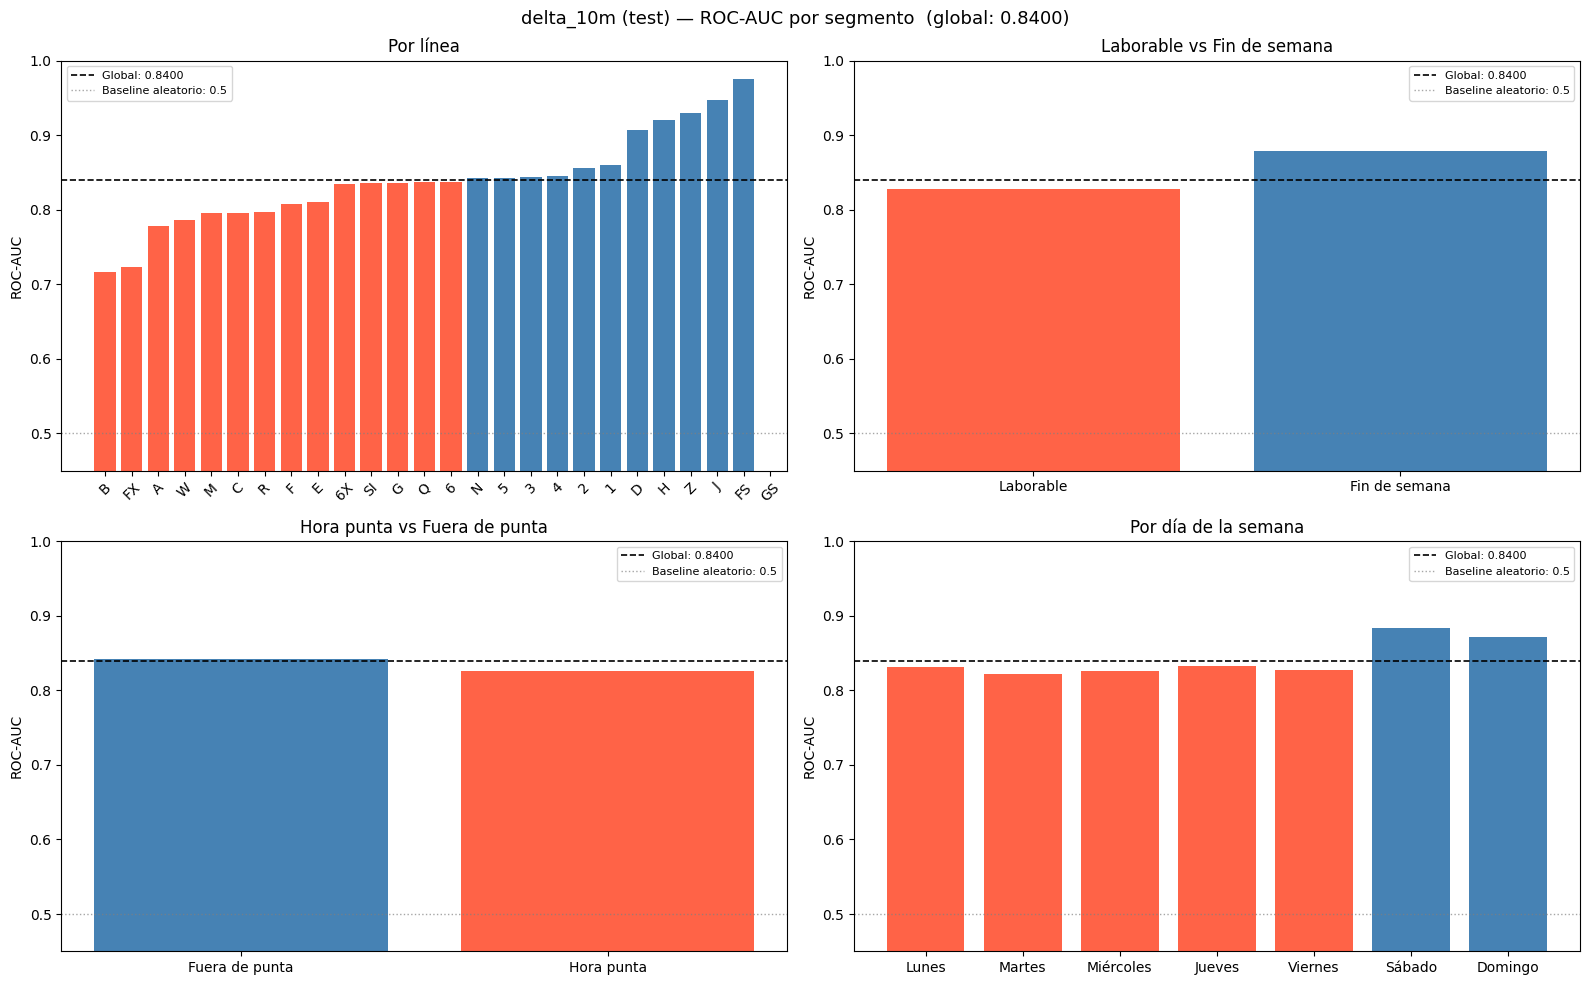

In [26]:
# bl10:   ROC-AUC agrupado por línea de metro (route_id)
# we10:   ROC-AUC por tipo de día (laborable vs fin de semana)
# rush10: ROC-AUC por franja horaria (hora punta 7-9h/17-19h vs fuera de punta)
# dow10:  ROC-AUC por día de la semana (lunes a domingo)
bl10, we10, rush10, dow10 = compute_slices_auc(te10, TARGET)

print(f'=== delta_10m — ROC-AUC global  val: {auc10_val:.4f}  |  test: {auc10_test:.4f} ===\n')

print('-- Por línea --')
print(bl10.sort_values('roc_auc').round(4).to_string(index=False))

print('\n-- Laborable vs Fin de semana --')
print(we10.round(4).to_string(index=False))

print('\n-- Hora punta vs Fuera de punta --')
print(rush10.round(4).to_string(index=False))

print('\n-- Por día de semana --')
print(dow10.round(4).to_string(index=False))

plot_slices_auc(bl10, we10, rush10, dow10, auc10_test, 'delta_10m (test)')

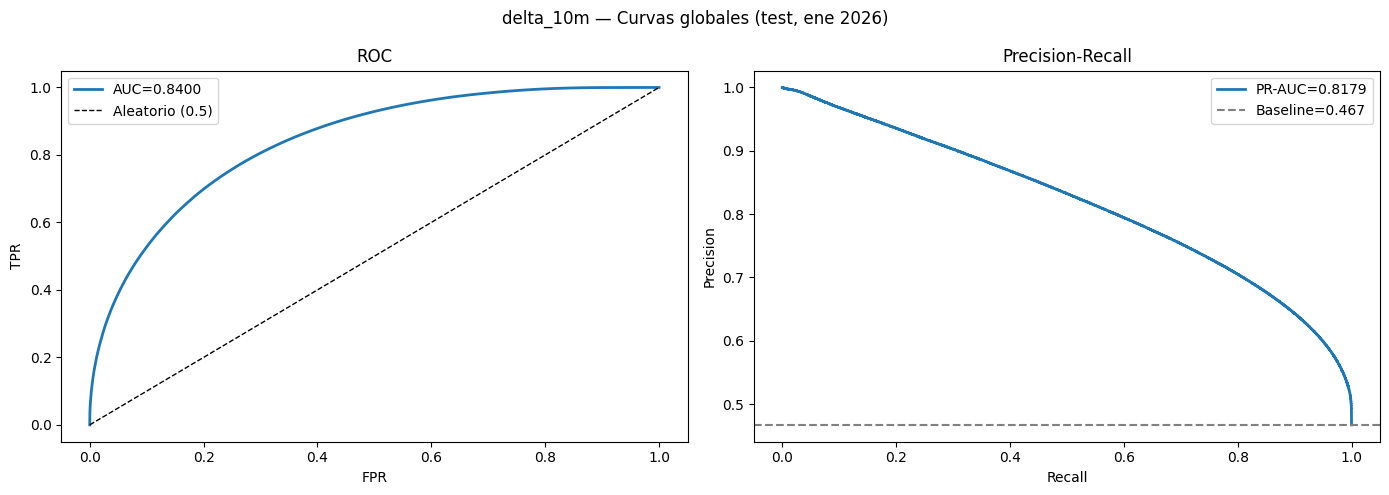

In [27]:
# Curvas ROC y PR (global, test)
fpr10, tpr10, _ = roc_curve(y_te10, te10['_pred_prob'])
prec10, rec10, _ = precision_recall_curve(y_te10, te10['_pred_prob'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('delta_10m — Curvas globales (test, ene 2026)', fontsize=12)

axes[0].plot(fpr10, tpr10, linewidth=2, label=f'AUC={auc10_test:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatorio (0.5)')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC'); axes[0].legend()

axes[1].plot(rec10, prec10, linewidth=2, label=f'PR-AUC={pr10_test:.4f}')
axes[1].axhline(float(y_te10.mean()), color='gray', linestyle='--',
                label=f'Baseline={float(y_te10.mean()):.3f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall'); axes[1].legend()

plt.tight_layout()
plt.show()

---
# Parte 2: delta_20m
Predice si el retraso mejora en los próximos **20 minutos**.

In [6]:
TARGET_DELTA_20M = 'delta_delay_20m'

print('Cargando train (ene-oct 2025) — delta_20m...')
tr20 = load_months(2025, range(1, 11), TARGET_DELTA_20M)
print(f'  Total train: {len(tr20):,} filas\n')

print('Cargando val (nov-dic 2025) — delta_20m...')
val20 = load_months(2025, range(11, 13), TARGET_DELTA_20M)
print(f'  Total val:   {len(val20):,} filas\n')

print('Cargando test (ene 2026) — delta_20m...')
te20 = load_months(2026, range(1, 2), TARGET_DELTA_20M)
print(f'  Total test:  {len(te20):,} filas')

Cargando train (ene-oct 2025) — delta_20m...
  2025-01: 4,587,704 filas
  2025-02: 4,219,476 filas
  2025-03: 3,993,627 filas
  2025-04: 4,468,429 filas
  2025-05: 4,445,274 filas
  2025-06: 4,379,084 filas
  2025-07: 4,548,226 filas
  2025-08: 4,585,476 filas
  2025-09: 4,553,791 filas
  2025-10: error (HTTPSConnectionPool(host='minio.fdi.ucm.es', port=443): Read timed out.)
  Total train: 39,781,087 filas

Cargando val (nov-dic 2025) — delta_20m...
  2025-11: 4,387,315 filas
  2025-12: 4,799,289 filas
  Total val:   9,186,604 filas

Cargando test (ene 2026) — delta_20m...
  2026-01: 4,537,749 filas
  Total test:  4,537,749 filas


In [7]:
tr20  = add_slice_cols(tr20)
val20 = add_slice_cols(val20)
te20  = add_slice_cols(te20)

tr20  = add_features(tr20)
val20 = add_features(val20)
te20  = add_features(te20)

tr20[TARGET]  = (tr20[TARGET_DELTA_20M]  < 0).astype(np.int8)
val20[TARGET] = (val20[TARGET_DELTA_20M] < 0).astype(np.int8)
te20[TARGET]  = (te20[TARGET_DELTA_20M]  < 0).astype(np.int8)

counts_tr = tr20[TARGET].value_counts().sort_index()
print(f'Train  — Clase 0: {counts_tr[0]:,}  |  Clase 1: {counts_tr[1]:,}  |  ratio clase 1: {counts_tr[1]/len(tr20):.3f}')
counts_te = te20[TARGET].value_counts().sort_index()
print(f'Test   — Clase 0: {counts_te[0]:,}  |  Clase 1: {counts_te[1]:,}  |  ratio clase 1: {counts_te[1]/len(te20):.3f}')

tr20, val20, te20 = encode_categoricals(tr20, val20, te20)

feats20 = get_features(tr20, TARGET)
print(f'\nFeatures ({len(feats20)}): {feats20}')

Train  — Clase 0: 20,899,622  |  Clase 1: 18,881,465  |  ratio clase 1: 0.475
Test   — Clase 0: 2,402,920  |  Clase 1: 2,134,829  |  ratio clase 1: 0.470

Features (36): ['stop_id', 'route_id', 'direction', 'delay_seconds', 'lagged_delay_1', 'lagged_delay_2', 'route_rolling_delay', 'actual_headway_seconds', 'hour_sin', 'hour_cos', 'dow', 'is_weekend', 'station_delay_10m', 'station_delay_20m', 'station_delay_30m', 'stops_to_end', 'scheduled_time_to_end', 'temp_extreme', 'n_eventos_afectando', 'tipo_referente', 'afecta_previo', 'afecta_durante', 'afecta_despues', 'category', 'num_updates', 'seconds_since_last_alert', 'is_alert_just_published', 'delay_change', 'delay_change_prev', 'delay_accel', 'delay_vs_route', 'delay_vs_station', 'station_trend', 'delay_time_ratio', 'has_alert', 'alert_impact']


In [8]:
X_tr20,  y_tr20  = tr20[feats20],  tr20[TARGET]
X_val20, y_val20 = val20[feats20], val20[TARGET]
X_te20,  y_te20  = te20[feats20],  te20[TARGET]

class_ratio20 = float(y_tr20.mean())
params20 = {**LGBM_PARAMS, 'is_unbalance': class_ratio20 < 0.3 or class_ratio20 > 0.7}
print(f'Clase 1 en train: {class_ratio20:.3f}  →  is_unbalance={params20["is_unbalance"]}')

print(f'\nEntrenando LGBM delta_20m...')
model20 = lgb.train(
    params20,
    lgb.Dataset(X_tr20, label=y_tr20),
    num_boost_round=NUM_BOOST_ROUND,
    valid_sets=[lgb.Dataset(X_val20, label=y_val20)],
    callbacks=[
        lgb.early_stopping(EARLY_STOPPING, verbose=False),
        lgb.log_evaluation(200),
    ],
)
print(f'\nMejor iteración: {model20.best_iteration}')

te20['_pred_prob']  = model20.predict(X_te20,  num_iteration=model20.best_iteration)
val20['_pred_prob'] = model20.predict(X_val20, num_iteration=model20.best_iteration)

auc20_val  = roc_auc_score(y_val20, val20['_pred_prob'])
auc20_test = roc_auc_score(y_te20,  te20['_pred_prob'])
pr20_test  = average_precision_score(y_te20, te20['_pred_prob'])

print(f'\nMétricas delta_20m:')
print(f'  Val  (nov-dic 2025): ROC-AUC={auc20_val:.4f}')
print(f'  Test (ene 2026):     ROC-AUC={auc20_test:.4f}  |  PR-AUC={pr20_test:.4f}')
print(f'  Gap val→test:        {auc20_test - auc20_val:+.4f}')

Clase 1 en train: 0.475  →  is_unbalance=False

Entrenando LGBM delta_20m...
[200]	valid_0's auc: 0.783902
[400]	valid_0's auc: 0.796355
[600]	valid_0's auc: 0.802195
[800]	valid_0's auc: 0.806072
[1000]	valid_0's auc: 0.808744
[1200]	valid_0's auc: 0.810996
[1400]	valid_0's auc: 0.812828
[1600]	valid_0's auc: 0.814363
[1800]	valid_0's auc: 0.815517
[2000]	valid_0's auc: 0.816655
[2200]	valid_0's auc: 0.817677
[2400]	valid_0's auc: 0.818644
[2600]	valid_0's auc: 0.819415
[2800]	valid_0's auc: 0.820099
[3000]	valid_0's auc: 0.820747

Mejor iteración: 3000

Métricas delta_20m:
  Val  (nov-dic 2025): ROC-AUC=0.8207
  Test (ene 2026):     ROC-AUC=0.8228  |  PR-AUC=0.8021
  Gap val→test:        +0.0020


=== delta_20m — ROC-AUC global  val: 0.8207  |  test: 0.8228 ===

-- Por línea --
linea  n_filas  roc_auc  pr_auc
   FX   2704.0   0.6857  0.7838
    B 116074.0   0.7250  0.7234
    R 284650.0   0.7664  0.8397
    W  74267.0   0.7702  0.8163
    A 275029.0   0.7759  0.7889
    M 117464.0   0.7842  0.8294
    3 202252.0   0.7920  0.7275
    F 306917.0   0.7938  0.8145
    6 361024.0   0.7971  0.6792
   6X  48328.0   0.7977  0.6876
    4 263170.0   0.8079  0.7239
    E 203822.0   0.8097  0.8526
    5 226499.0   0.8107  0.7613
    G 148903.0   0.8109  0.7203
    Q 228993.0   0.8132  0.8055
    C 204114.0   0.8186  0.8590
    N 202060.0   0.8186  0.8074
    2 370497.0   0.8254  0.7588
   SI  21484.0   0.8405  0.6739
    1 402108.0   0.8444  0.7946
    D 226929.0   0.8987  0.8501
    Z   4470.0   0.9120  0.8499
    J 189042.0   0.9150  0.9069
    H  22845.0   0.9198  0.9434
   FS  20788.0   0.9762  0.9836
   GS  13316.0      NaN     NaN

-- Laborable vs Fin de semana --
  n_filas  roc_auc  

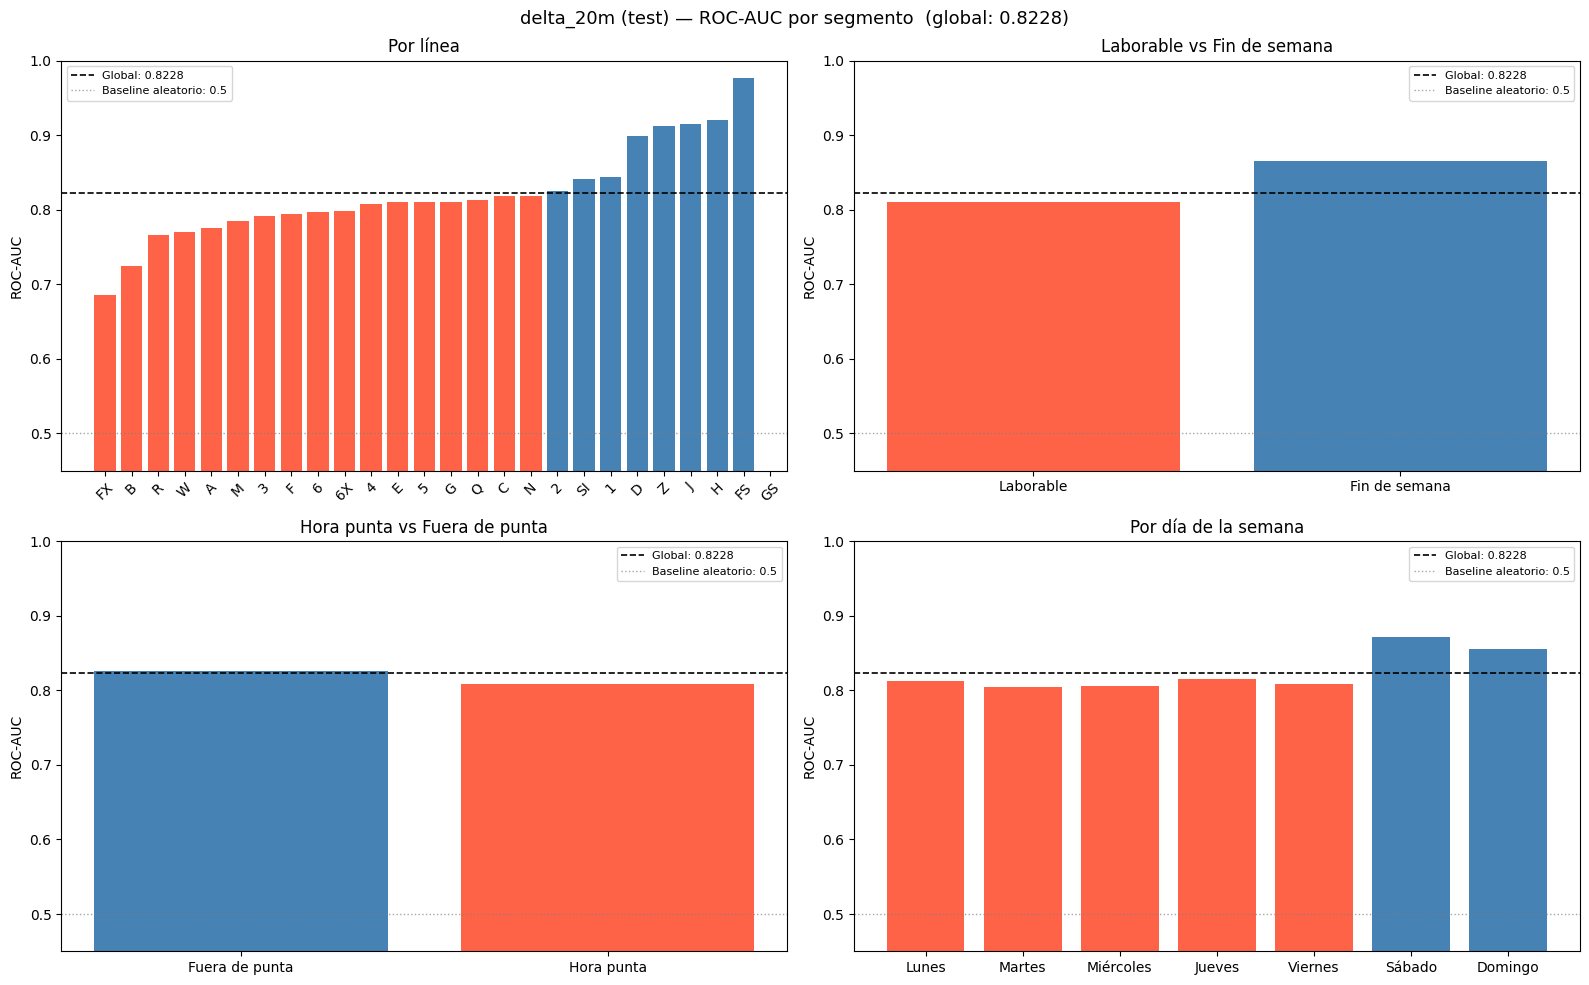

In [9]:
# bl20:   ROC-AUC agrupado por línea de metro (route_id)
# we20:   ROC-AUC por tipo de día (laborable vs fin de semana)
# rush20: ROC-AUC por franja horaria (hora punta 7-9h/17-19h vs fuera de punta)
# dow20:  ROC-AUC por día de la semana (lunes a domingo)
bl20, we20, rush20, dow20 = compute_slices_auc(te20, TARGET)

print(f'=== delta_20m — ROC-AUC global  val: {auc20_val:.4f}  |  test: {auc20_test:.4f} ===\n')

print('-- Por línea --')
print(bl20.sort_values('roc_auc').round(4).to_string(index=False))

print('\n-- Laborable vs Fin de semana --')
print(we20.round(4).to_string(index=False))

print('\n-- Hora punta vs Fuera de punta --')
print(rush20.round(4).to_string(index=False))

print('\n-- Por día de semana --')
print(dow20.round(4).to_string(index=False))

plot_slices_auc(bl20, we20, rush20, dow20, auc20_test, 'delta_20m (test)')

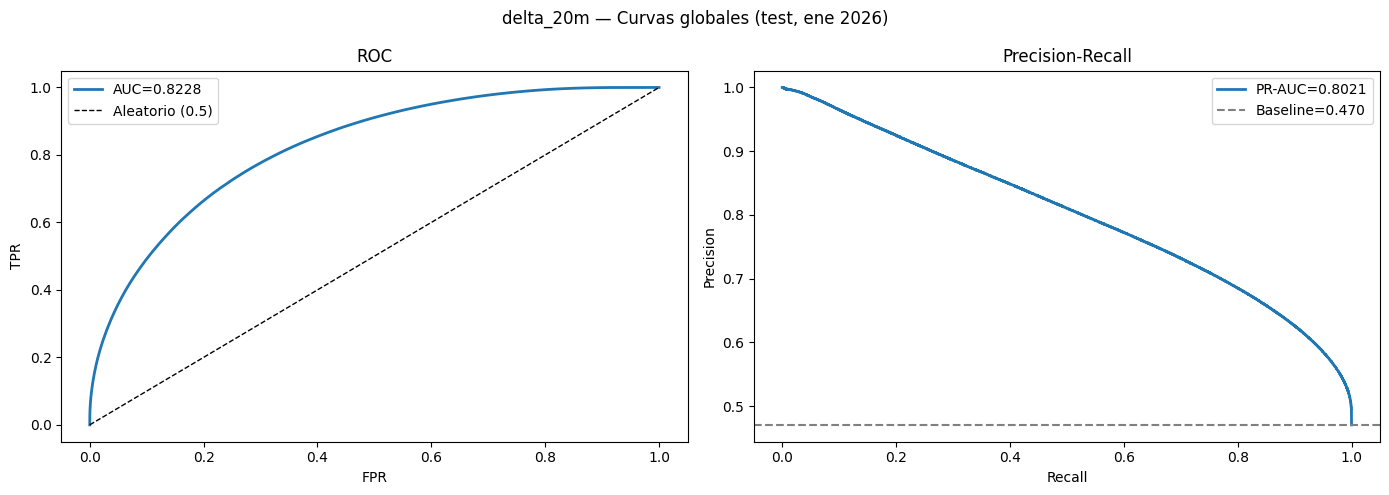

In [10]:
fpr20, tpr20, _ = roc_curve(y_te20, te20['_pred_prob'])
prec20, rec20, _ = precision_recall_curve(y_te20, te20['_pred_prob'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('delta_20m — Curvas globales (test, ene 2026)', fontsize=12)

axes[0].plot(fpr20, tpr20, linewidth=2, label=f'AUC={auc20_test:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatorio (0.5)')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC'); axes[0].legend()

axes[1].plot(rec20, prec20, linewidth=2, label=f'PR-AUC={pr20_test:.4f}')
axes[1].axhline(float(y_te20.mean()), color='gray', linestyle='--',
                label=f'Baseline={float(y_te20.mean()):.3f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall'); axes[1].legend()

plt.tight_layout()
plt.show()

---
# Parte 3: delta_30m
Predice si el retraso mejora en los próximos **30 minutos**.

In [5]:
TARGET_DELTA_30M = 'delta_delay_30m'

print('Cargando train (ene-oct 2025) — delta_30m...')
tr30 = load_months(2025, range(1, 11), TARGET_DELTA_30M)
print(f'  Total train: {len(tr30):,} filas\n')

print('Cargando val (nov-dic 2025) — delta_30m...')
val30 = load_months(2025, range(11, 13), TARGET_DELTA_30M)
print(f'  Total val:   {len(val30):,} filas\n')

print('Cargando test (ene 2026) — delta_30m...')
te30 = load_months(2026, range(1, 2), TARGET_DELTA_30M)
print(f'  Total test:  {len(te30):,} filas')

Cargando train (ene-oct 2025) — delta_30m...
  2025-01: 4,587,704 filas
  2025-02: 4,219,476 filas
  2025-03: 3,993,627 filas
  2025-04: 4,468,429 filas
  2025-05: 4,445,274 filas
  2025-06: 4,379,084 filas
  2025-07: 4,548,226 filas
  2025-08: 4,585,476 filas
  2025-09: 4,553,791 filas
  2025-10: 4,825,342 filas
  Total train: 44,606,429 filas

Cargando val (nov-dic 2025) — delta_30m...
  2025-11: 4,387,315 filas
  2025-12: 4,799,289 filas
  Total val:   9,186,604 filas

Cargando test (ene 2026) — delta_30m...
  2026-01: 4,537,749 filas
  Total test:  4,537,749 filas


In [6]:
tr30  = add_slice_cols(tr30)
val30 = add_slice_cols(val30)
te30  = add_slice_cols(te30)

tr30  = add_features(tr30)
val30 = add_features(val30)
te30  = add_features(te30)

tr30[TARGET]  = (tr30[TARGET_DELTA_30M]  < 0).astype(np.int8)
val30[TARGET] = (val30[TARGET_DELTA_30M] < 0).astype(np.int8)
te30[TARGET]  = (te30[TARGET_DELTA_30M]  < 0).astype(np.int8)

counts_tr = tr30[TARGET].value_counts().sort_index()
print(f'Train  — Clase 0: {counts_tr[0]:,}  |  Clase 1: {counts_tr[1]:,}  |  ratio clase 1: {counts_tr[1]/len(tr30):.3f}')
counts_te = te30[TARGET].value_counts().sort_index()
print(f'Test   — Clase 0: {counts_te[0]:,}  |  Clase 1: {counts_te[1]:,}  |  ratio clase 1: {counts_te[1]/len(te30):.3f}')

tr30, val30, te30 = encode_categoricals(tr30, val30, te30)

feats30 = get_features(tr30, TARGET)
print(f'\nFeatures ({len(feats30)}): {feats30}')

Train  — Clase 0: 23,080,164  |  Clase 1: 21,526,265  |  ratio clase 1: 0.483
Test   — Clase 0: 2,371,946  |  Clase 1: 2,165,803  |  ratio clase 1: 0.477

Features (36): ['stop_id', 'route_id', 'direction', 'delay_seconds', 'lagged_delay_1', 'lagged_delay_2', 'route_rolling_delay', 'actual_headway_seconds', 'hour_sin', 'hour_cos', 'dow', 'is_weekend', 'station_delay_10m', 'station_delay_20m', 'station_delay_30m', 'stops_to_end', 'scheduled_time_to_end', 'temp_extreme', 'n_eventos_afectando', 'tipo_referente', 'afecta_previo', 'afecta_durante', 'afecta_despues', 'category', 'num_updates', 'seconds_since_last_alert', 'is_alert_just_published', 'delay_change', 'delay_change_prev', 'delay_accel', 'delay_vs_route', 'delay_vs_station', 'station_trend', 'delay_time_ratio', 'has_alert', 'alert_impact']


In [7]:
X_tr30,  y_tr30  = tr30[feats30],  tr30[TARGET]
X_val30, y_val30 = val30[feats30], val30[TARGET]
X_te30,  y_te30  = te30[feats30],  te30[TARGET]

class_ratio30 = float(y_tr30.mean())
params30 = {**LGBM_PARAMS, 'is_unbalance': class_ratio30 < 0.3 or class_ratio30 > 0.7}
print(f'Clase 1 en train: {class_ratio30:.3f}  →  is_unbalance={params30["is_unbalance"]}')

print(f'\nEntrenando LGBM delta_30m...')
model30 = lgb.train(
    params30,
    lgb.Dataset(X_tr30, label=y_tr30),
    num_boost_round=NUM_BOOST_ROUND,
    valid_sets=[lgb.Dataset(X_val30, label=y_val30)],
    callbacks=[
        lgb.early_stopping(EARLY_STOPPING, verbose=False),
        lgb.log_evaluation(200),
    ],
)
print(f'\nMejor iteración: {model30.best_iteration}')

te30['_pred_prob']  = model30.predict(X_te30,  num_iteration=model30.best_iteration)
val30['_pred_prob'] = model30.predict(X_val30, num_iteration=model30.best_iteration)

auc30_val  = roc_auc_score(y_val30, val30['_pred_prob'])
auc30_test = roc_auc_score(y_te30,  te30['_pred_prob'])
pr30_test  = average_precision_score(y_te30, te30['_pred_prob'])

print(f'\nMétricas delta_30m:')
print(f'  Val  (nov-dic 2025): ROC-AUC={auc30_val:.4f}')
print(f'  Test (ene 2026):     ROC-AUC={auc30_test:.4f}  |  PR-AUC={pr30_test:.4f}')
print(f'  Gap val→test:        {auc30_test - auc30_val:+.4f}')

Clase 1 en train: 0.483  →  is_unbalance=False

Entrenando LGBM delta_30m...
[200]	valid_0's auc: 0.790963
[400]	valid_0's auc: 0.801888
[600]	valid_0's auc: 0.807519
[800]	valid_0's auc: 0.811183
[1000]	valid_0's auc: 0.813981
[1200]	valid_0's auc: 0.816134
[1400]	valid_0's auc: 0.817594
[1600]	valid_0's auc: 0.819162
[1800]	valid_0's auc: 0.820341
[2000]	valid_0's auc: 0.82141
[2200]	valid_0's auc: 0.822386
[2400]	valid_0's auc: 0.823187
[2600]	valid_0's auc: 0.823989
[2800]	valid_0's auc: 0.82456
[3000]	valid_0's auc: 0.825072

Mejor iteración: 3000

Métricas delta_30m:
  Val  (nov-dic 2025): ROC-AUC=0.8251
  Test (ene 2026):     ROC-AUC=0.8241  |  PR-AUC=0.8073
  Gap val→test:        -0.0009


=== delta_30m — ROC-AUC global  val: 0.8251  |  test: 0.8241 ===

-- Por línea --
linea  n_filas  roc_auc  pr_auc
   FX   2704.0   0.6313  0.7667
    B 116074.0   0.7381  0.7264
    R 284650.0   0.7730  0.8589
    M 117464.0   0.7790  0.8356
    W  74267.0   0.7830  0.8301
    3 202252.0   0.7874  0.6916
    A 275029.0   0.7918  0.8091
    F 306917.0   0.7948  0.8274
    5 226499.0   0.7951  0.7480
   6X  48328.0   0.7979  0.6772
    6 361024.0   0.8029  0.6599
    4 263170.0   0.8062  0.7145
    G 148903.0   0.8071  0.7240
    N 202060.0   0.8092  0.8104
    Q 228993.0   0.8104  0.8035
    E 203822.0   0.8157  0.8656
    2 370497.0   0.8166  0.7424
    1 402108.0   0.8273  0.7898
    C 204114.0   0.8318  0.8801
   SI  21484.0   0.8559  0.6540
    J 189042.0   0.8951  0.8949
    D 226929.0   0.9045  0.8681
    Z   4470.0   0.9159  0.8590
    H  22845.0   0.9223  0.9457
   FS  20788.0   0.9767  0.9840
   GS  13316.0      NaN     NaN

-- Laborable vs Fin de semana --
  n_filas  roc_auc  

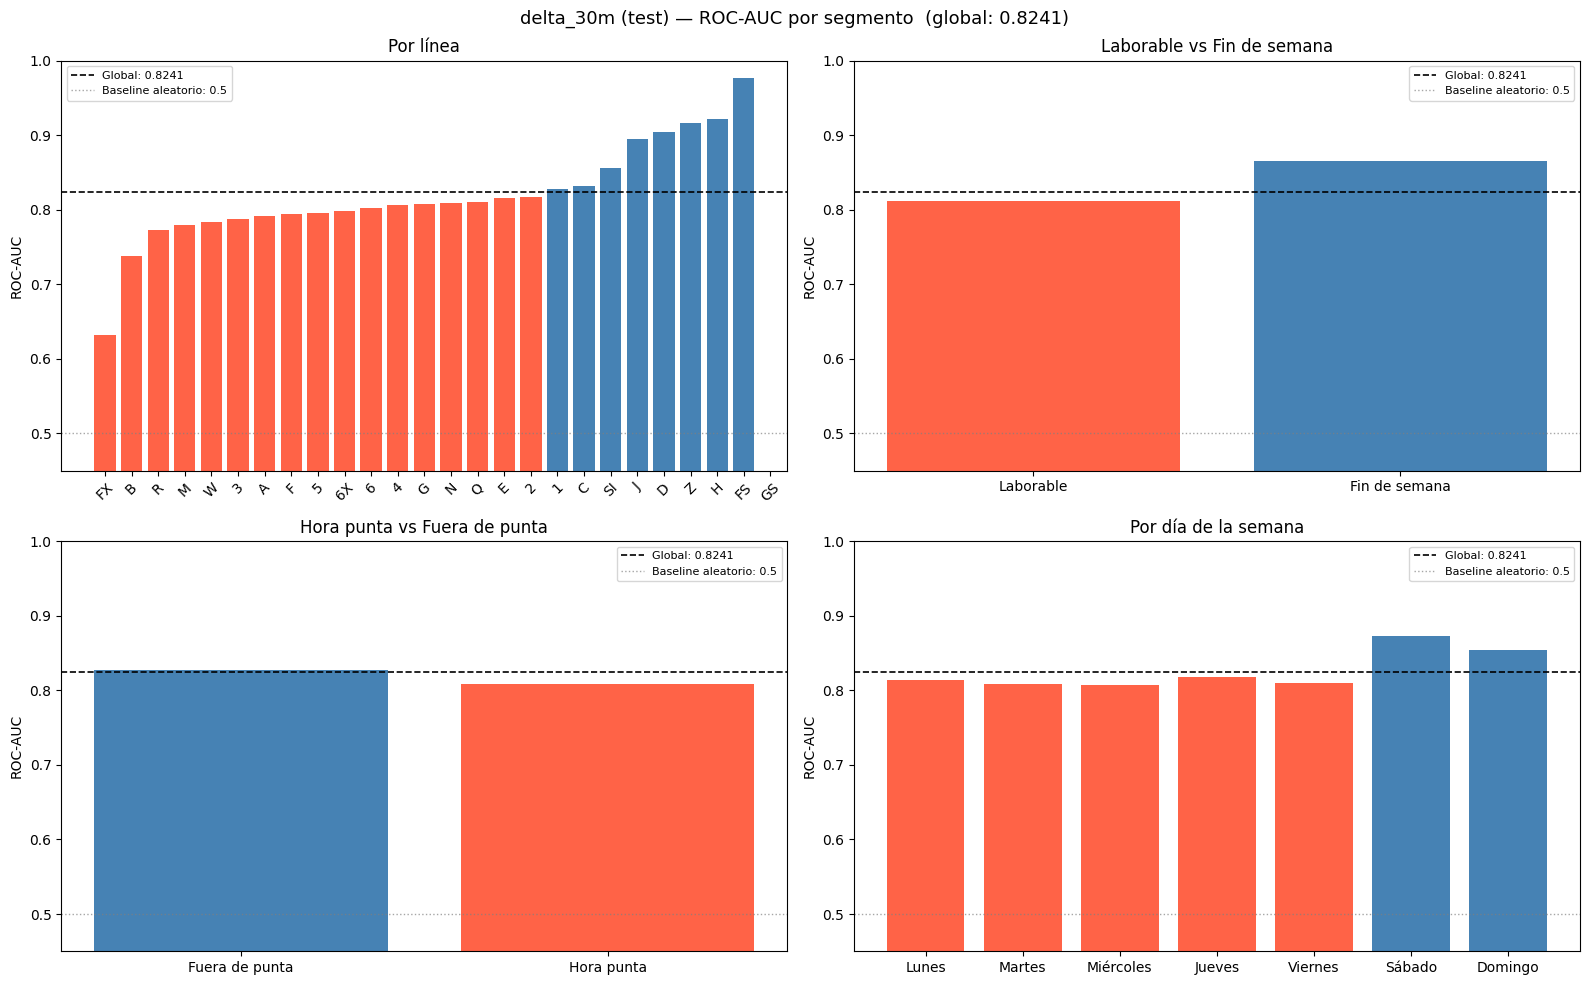

In [8]:
# bl30:   ROC-AUC agrupado por línea de metro (route_id)
# we30:   ROC-AUC por tipo de día (laborable vs fin de semana)
# rush30: ROC-AUC por franja horaria (hora punta 7-9h/17-19h vs fuera de punta)
# dow30:  ROC-AUC por día de la semana (lunes a domingo)
bl30, we30, rush30, dow30 = compute_slices_auc(te30, TARGET)

print(f'=== delta_30m — ROC-AUC global  val: {auc30_val:.4f}  |  test: {auc30_test:.4f} ===\n')

print('-- Por línea --')
print(bl30.sort_values('roc_auc').round(4).to_string(index=False))

print('\n-- Laborable vs Fin de semana --')
print(we30.round(4).to_string(index=False))

print('\n-- Hora punta vs Fuera de punta --')
print(rush30.round(4).to_string(index=False))

print('\n-- Por día de semana --')
print(dow30.round(4).to_string(index=False))

plot_slices_auc(bl30, we30, rush30, dow30, auc30_test, 'delta_30m (test)')

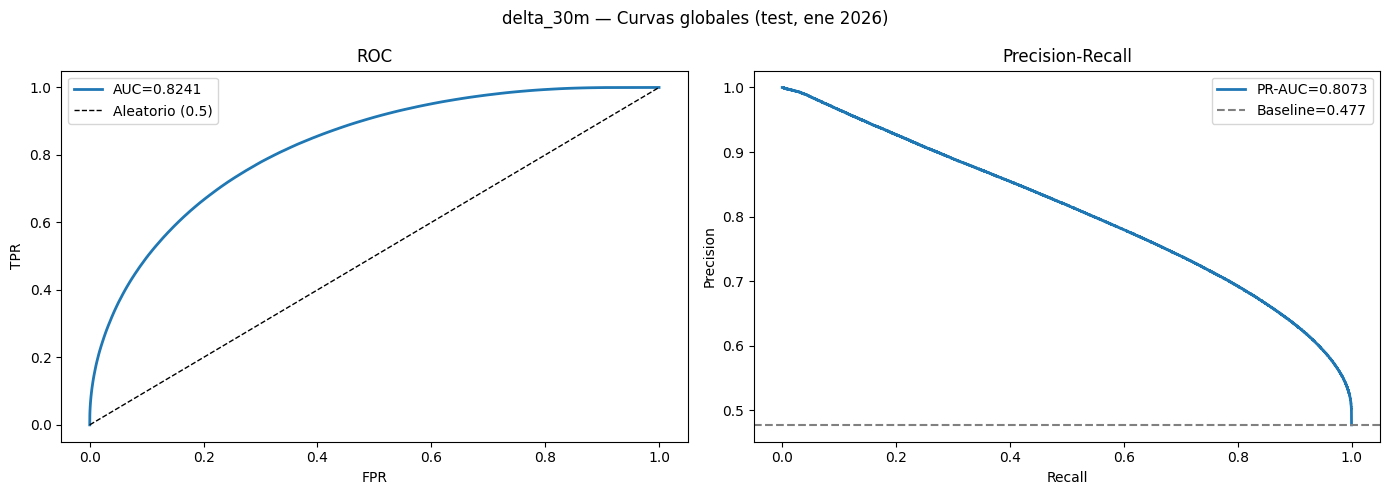

In [9]:
fpr30, tpr30, _ = roc_curve(y_te30, te30['_pred_prob'])
prec30, rec30, _ = precision_recall_curve(y_te30, te30['_pred_prob'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('delta_30m — Curvas globales (test, ene 2026)', fontsize=12)

axes[0].plot(fpr30, tpr30, linewidth=2, label=f'AUC={auc30_test:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatorio (0.5)')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC'); axes[0].legend()

axes[1].plot(rec30, prec30, linewidth=2, label=f'PR-AUC={pr30_test:.4f}')
axes[1].axhline(float(y_te30.mean()), color='gray', linestyle='--',
                label=f'Baseline={float(y_te30.mean()):.3f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall'); axes[1].legend()

plt.tight_layout()
plt.show()

---
# Resumen comparativo

In [ ]:
print('=' * 65)
print('RESUMEN GLOBAL (test — ene 2026)')
print('=' * 65)
print(f'{"":25} {"delta_10m":>12} {"delta_20m":>12} {"delta_30m":>12}')
print(f'{"Val ROC-AUC":25} {auc10_val:>12.4f} {auc20_val:>12.4f} {auc30_val:>12.4f}')
print(f'{"Test ROC-AUC":25} {auc10_test:>12.4f} {auc20_test:>12.4f} {auc30_test:>12.4f}')
print(f'{"Test PR-AUC":25} {pr10_test:>12.4f} {pr20_test:>12.4f} {pr30_test:>12.4f}')
print(f'{"Gap val→test":25} {auc10_test - auc10_val:>+12.4f} {auc20_test - auc20_val:>+12.4f} {auc30_test - auc30_val:>+12.4f}')
print('=' * 65)

In [ ]:
# Comparativa por segmento
print('\n--- Laborable vs Fin de semana (test) ---')
comp_we = (
    we10[['tipo', 'roc_auc']].rename(columns={'roc_auc': 'roc_auc_10m'})
    .merge(we20[['tipo', 'roc_auc']].rename(columns={'roc_auc': 'roc_auc_20m'}), on='tipo')
    .merge(we30[['tipo', 'roc_auc']].rename(columns={'roc_auc': 'roc_auc_30m'}), on='tipo')
)
print(comp_we.round(4).to_string(index=False))

print('\n--- Hora punta vs Fuera de punta (test) ---')
comp_rush = (
    rush10[['tipo', 'roc_auc']].rename(columns={'roc_auc': 'roc_auc_10m'})
    .merge(rush20[['tipo', 'roc_auc']].rename(columns={'roc_auc': 'roc_auc_20m'}), on='tipo')
    .merge(rush30[['tipo', 'roc_auc']].rename(columns={'roc_auc': 'roc_auc_30m'}), on='tipo')
)
print(comp_rush.round(4).to_string(index=False))

print('\n--- Por día de semana (test) ---')
comp_dow = (
    dow10[['dia', 'roc_auc']].rename(columns={'roc_auc': 'roc_auc_10m'})
    .merge(dow20[['dia', 'roc_auc']].rename(columns={'roc_auc': 'roc_auc_20m'}), on='dia')
    .merge(dow30[['dia', 'roc_auc']].rename(columns={'roc_auc': 'roc_auc_30m'}), on='dia')
)
print(comp_dow.round(4).to_string(index=False))

In [ ]:
# Curvas ROC superpuestas (test)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Comparativa de horizontes — test (ene 2026)', fontsize=13)

for fpr, tpr, auc, label, color in [
    (fpr10, tpr10, auc10_test, f'delta_10m (AUC={auc10_test:.4f})', '#e74c3c'),
    (fpr20, tpr20, auc20_test, f'delta_20m (AUC={auc20_test:.4f})', '#3498db'),
    (fpr30, tpr30, auc30_test, f'delta_30m (AUC={auc30_test:.4f})', '#2ecc71'),
]:
    axes[0].plot(fpr, tpr, linewidth=2, label=label, color=color)
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatorio')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('Curvas ROC'); axes[0].legend(fontsize=9)

# ROC-AUC por día de semana (los tres horizontes)
dow_order = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
comp_dow_ord = comp_dow.set_index('dia').reindex(dow_order)
x = np.arange(len(dow_order))
width = 0.25
axes[1].bar(x - width, comp_dow_ord['roc_auc_10m'], width, label='delta_10m', color='#e74c3c')
axes[1].bar(x,         comp_dow_ord['roc_auc_20m'], width, label='delta_20m', color='#3498db')
axes[1].bar(x + width, comp_dow_ord['roc_auc_30m'], width, label='delta_30m', color='#2ecc71')
axes[1].set_xticks(x)
axes[1].set_xticklabels(dow_order, rotation=30)
axes[1].set_ylabel('ROC-AUC')
axes[1].set_ylim(0.45, 1.0)
axes[1].set_title('ROC-AUC por día de semana')
axes[1].legend(fontsize=9)
axes[1].axhline(0.5, color='gray', linestyle=':', linewidth=1, alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# ROC-AUC por línea — comparativa de horizontes
comp_line = (
    bl10[['linea', 'roc_auc']].rename(columns={'roc_auc': 'roc_auc_10m'})
    .merge(bl20[['linea', 'roc_auc']].rename(columns={'roc_auc': 'roc_auc_20m'}), on='linea')
    .merge(bl30[['linea', 'roc_auc']].rename(columns={'roc_auc': 'roc_auc_30m'}), on='linea')
).dropna()

print('--- Por línea (test) ---')
print(comp_line.sort_values('roc_auc_10m').round(4).to_string(index=False))

# Gráfico comparativo por línea
comp_line_sorted = comp_line.sort_values('roc_auc_10m').reset_index(drop=True)
x = np.arange(len(comp_line_sorted))
width = 0.25

fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(x - width, comp_line_sorted['roc_auc_10m'], width, label='delta_10m', color='#e74c3c')
ax.bar(x,         comp_line_sorted['roc_auc_20m'], width, label='delta_20m', color='#3498db')
ax.bar(x + width, comp_line_sorted['roc_auc_30m'], width, label='delta_30m', color='#2ecc71')
ax.set_xticks(x)
ax.set_xticklabels(comp_line_sorted['linea'], rotation=45)
ax.set_ylabel('ROC-AUC')
ax.set_ylim(0.45, 1.0)
ax.set_title('ROC-AUC por línea — comparativa de horizontes (test, ene 2026)')
ax.legend(fontsize=10)
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1, alpha=0.7, label='Baseline')
plt.tight_layout()
plt.show()